In [ ]:
# Predicción de Precios de Vivienda con Random Forest Regressor, Regresión Lineal, Adaboost y XGBoost
#https://www.kaggle.com/datasets/camnugent/california-housing-prices
from sklearn.datasets import fetch_california_housing
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
data = fetch_california_housing(as_frame=True)
df = data.frame



1. longitude: A measure of how far west a house is; a higher value is farther west

2. latitude: A measure of how far north a house is; a higher value is farther north

3. housingMedianAge: Median age of a house within a block; a lower number is a newer building

4. totalRooms: Total number of rooms within a block

5. totalBedrooms: Total number of bedrooms within a block

6. population: Total number of people residing within a block

7. households: Total number of households, a group of people residing within a home unit, for a block

8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)

9. medianHouseValue: Median house value for households within a block (measured in US Dollars)

10. oceanProximity: Location of the house w.r.t ocean/sea

In [ ]:
df.head(50)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [ ]:
# Split features & target
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize numeric variables
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Regresión Lineal

In [ ]:
#Regresión Lineal

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
preds_lr = lin_reg.predict(X_test)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, preds_lr)
rmse = np.sqrt(mean_squared_error(y_test, preds_lr))
r2 = r2_score(y_test, preds_lr)

print(f"Linear Regression Results:")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")


Linear Regression Results:
MAE:  0.527
RMSE: 0.728
R²:   0.596


In [ ]:
results = []
results.append(["Linear Regression", mae, rmse, r2])
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R²"])
print(results_df.sort_values(by="R²", ascending=False))


               Model       MAE      RMSE       R²
0  Linear Regression  0.527247  0.728401  0.59577


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Diferentes modelos en 1
models = {
    "RandomForest": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42),
    "Linear Regression": LinearRegression()
}


In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append([name, mae, rmse, r2])


results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R²"])
print(results_df)

               Model       MAE      RMSE        R²
0  Linear Regression  0.527247  0.728401  0.595770
1       RandomForest  0.346981  0.520303  0.793747
2  Linear Regression  0.527247  0.728401  0.595770


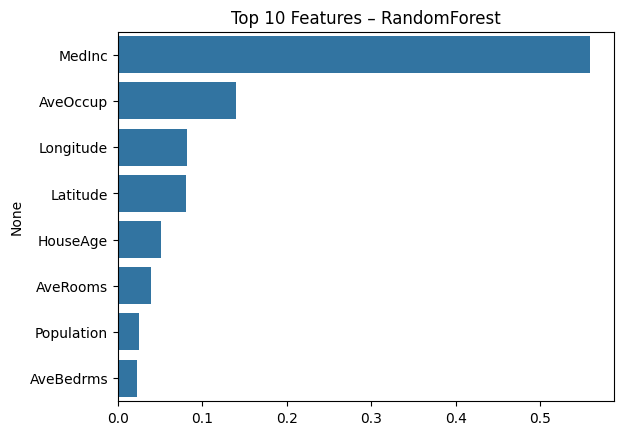

Linear Regression does not expose feature importances.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for name, model in models.items():
    try:
        importances = model.feature_importances_
        feat_imp = pd.Series(importances, index=data.feature_names).sort_values(ascending=False)
        sns.barplot(x=feat_imp.values[:10], y=feat_imp.index[:10])
        plt.title(f"Top 10 Features – {name}")
        plt.show()
    except AttributeError:
        print(f"{name} does not expose feature importances.")


In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor

# Add AdaBoost and XGBoost to the models dictionary
models["AdaBoost"] = AdaBoostRegressor(n_estimators=100, random_state=42)
models["XGBoost"] = XGBRegressor(n_estimators=100, random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    # Check if the model is already in the results list before appending
    if not any(d[0] == name for d in results):
        results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R²"])
print(results_df.sort_values(by="R²", ascending=False))

               Model       MAE      RMSE        R²
4            XGBoost  0.307246  0.460242  0.838616
1       RandomForest  0.346981  0.520303  0.793747
0  Linear Regression  0.527247  0.728401  0.595770
2  Linear Regression  0.527247  0.728401  0.595770
3           AdaBoost  0.707700  0.826424  0.479653


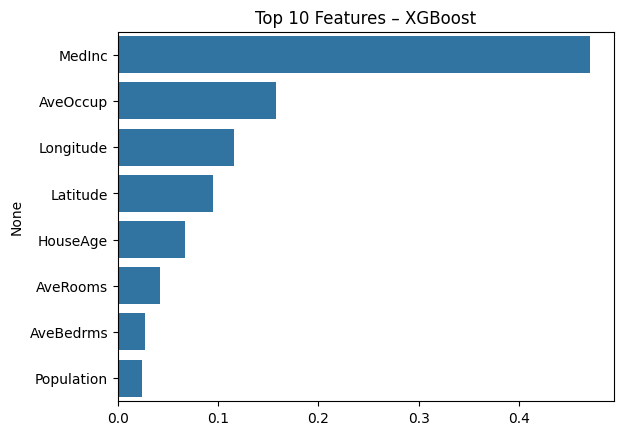

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'models' dictionary contains the trained XGBoost model
xgboost_model = models["XGBoost"]

try:
    importances = xgboost_model.feature_importances_
    feat_imp = pd.Series(importances, index=data.feature_names).sort_values(ascending=False)
    sns.barplot(x=feat_imp.values[:10], y=feat_imp.index[:10])
    plt.title("Top 10 Features – XGBoost")
    plt.show()
except AttributeError:
    print("XGBoost does not expose feature importances in this manner.")